In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

/tmp/ipykernel_241/1517503111.py:5: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory, NanoAODSchema


In [2]:
samples = [
    '2Mu2E_800GeV_5p0GeV_50p0mm',
    '2Mu2E_800GeV_1p2GeV_12p0mm',
    '2Mu2E_800GeV_0p25GeV_2p5mm',
    '2Mu2E_500GeV_5p0GeV_80p0mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',
    '2Mu2E_500GeV_0p25GeV_4p0mm',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    "baseNoTriggerNoLjNoLjsource",
    "notrigger_1dsamu",
    "notrigger_2dsamu",
    "noLj1dsamu",
    "noLj2dsamu",
    "notrigger_1dsamuCC",
    "notrigger_2dsamuCC",
    "noLj1dsamuCC",
    "noLj2dsamuCC",
    #"base_preCC",
    #"base_CC",
    "baseNoTriggerNoLjNoLjsourceCC",
    "noLjCC",
    "notriggerCC",
    #"testnoLj1dsamu",
    "notrigger_2pfmu",
    "noLj2pfmu",
    'noLj2pfmuCC',
]

#p = sidm_processor.SidmProcessor(
#    channels,
#    ["genA_toMu_base"],
#    verbose=True,
#)

p = sidm_processor.SidmProcessor(
    channels,
    ["genA_toMu_base"],
    verbose=True,
)

#output = runner.run(fileset, treename='Events', processor_instance=p)
#out = output["out"]

out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing 2Mu2E_800GeV_5p0GeV_50p0mm


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XXLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_MuMudR_highRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_highRange_MuMudR_lowRange could not be filled and will be skipped

Signal not in xs cfg, assuming 1fb


Text(0.5, 1.07, '2Mu2E_800GeV_5p0GeV_50p0mm')

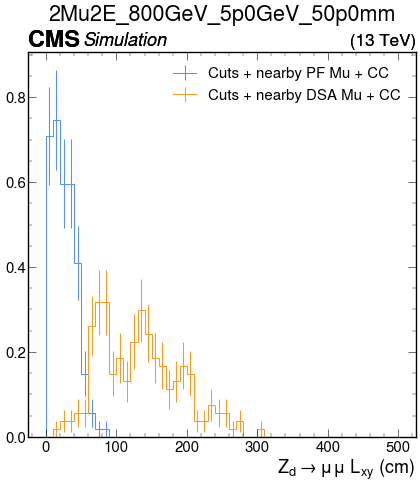

In [17]:
channel1 = 0
channel2 = 2
channel3 = 14
channel4 = 6
channel5 = 8
channel6 = 5
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label="Cuts + nearby PF Mu + CC")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label="Cuts + nearby DSA Mu + CC")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

Text(0.5, 1.07, '2Mu2E_800GeV_5p0GeV_50p0mm')

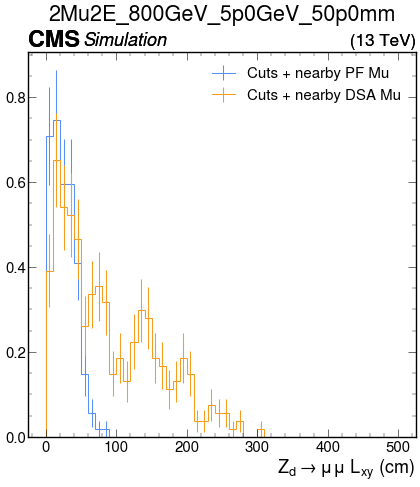

In [18]:
channel1 = 0
channel2 = 2
channel3 = 13
channel4 = 6
channel5 = 4
channel6 = 5
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label="Cuts + nearby PF Mu")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label="Cuts + nearby DSA Mu")
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

Text(0.5, 1.07, '2Mu2E_800GeV_5p0GeV_50p0mm')

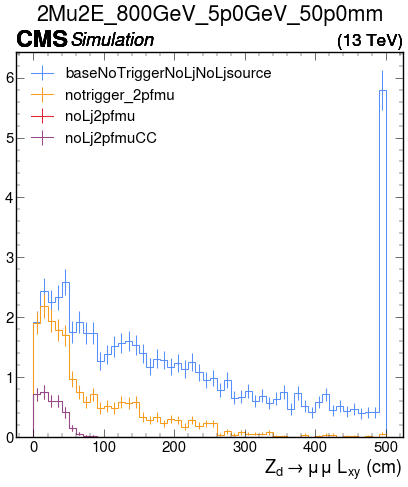

In [3]:
channel1 = 0
channel2 = 12
channel3 = 13
channel4 = 6
channel5 = 14
channel6 = 5
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
#utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

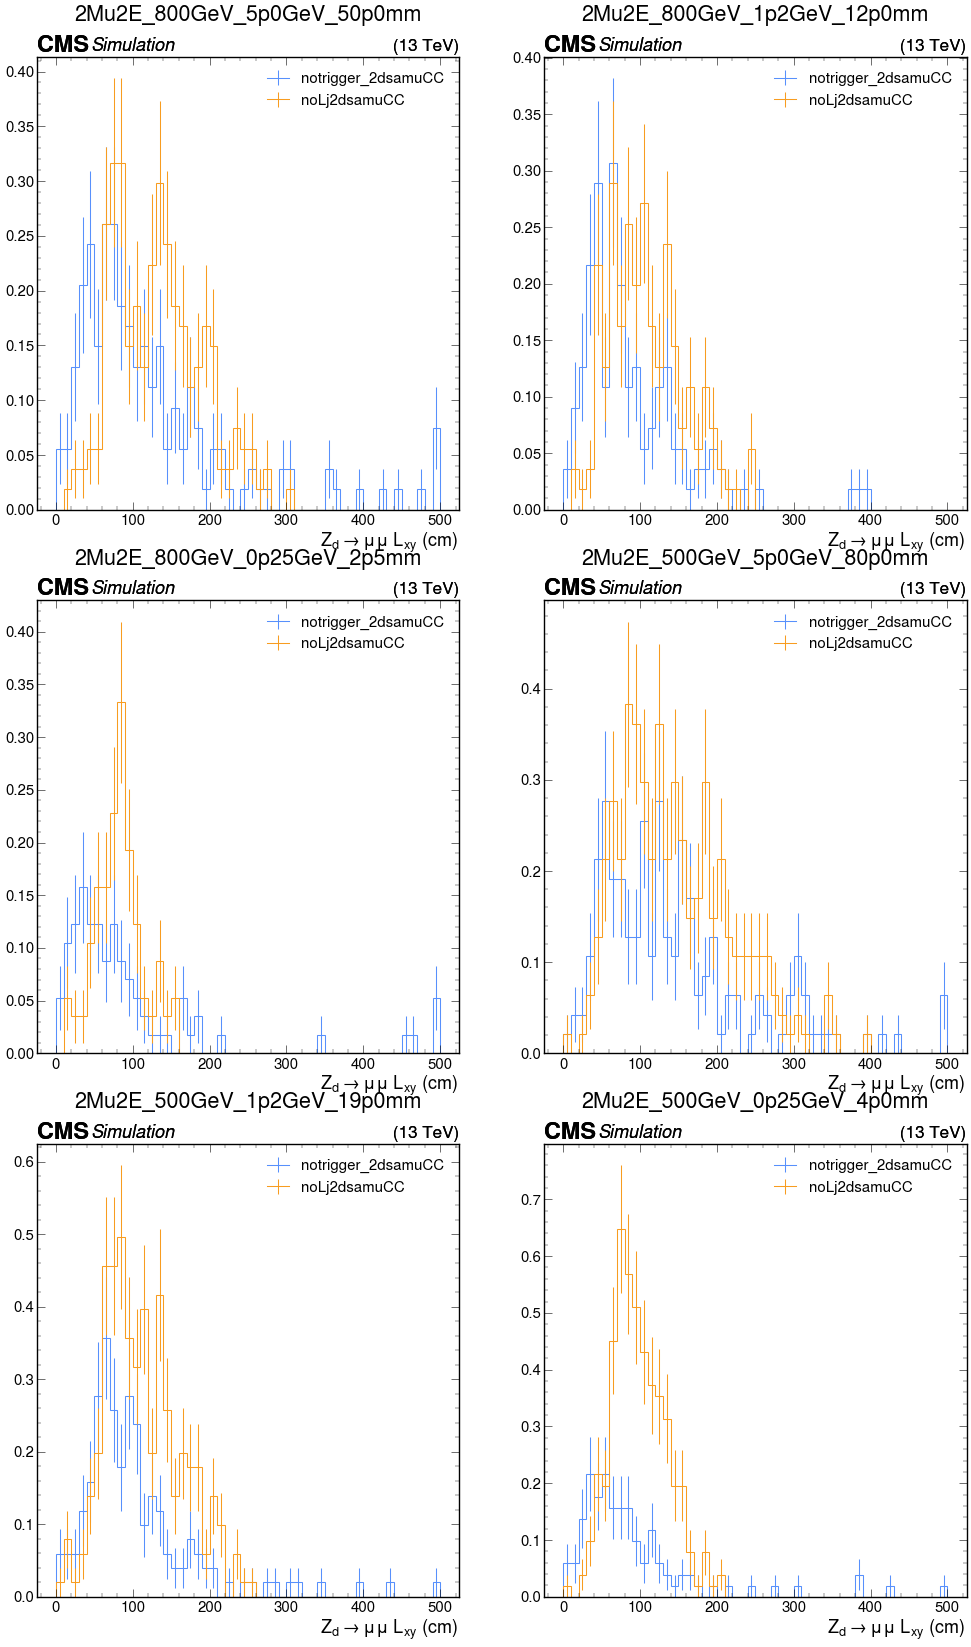

In [5]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 6
    channel2 = 8
    channel3 = 2
    channel4 = 3
    channel5 = 4
    #channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
   #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

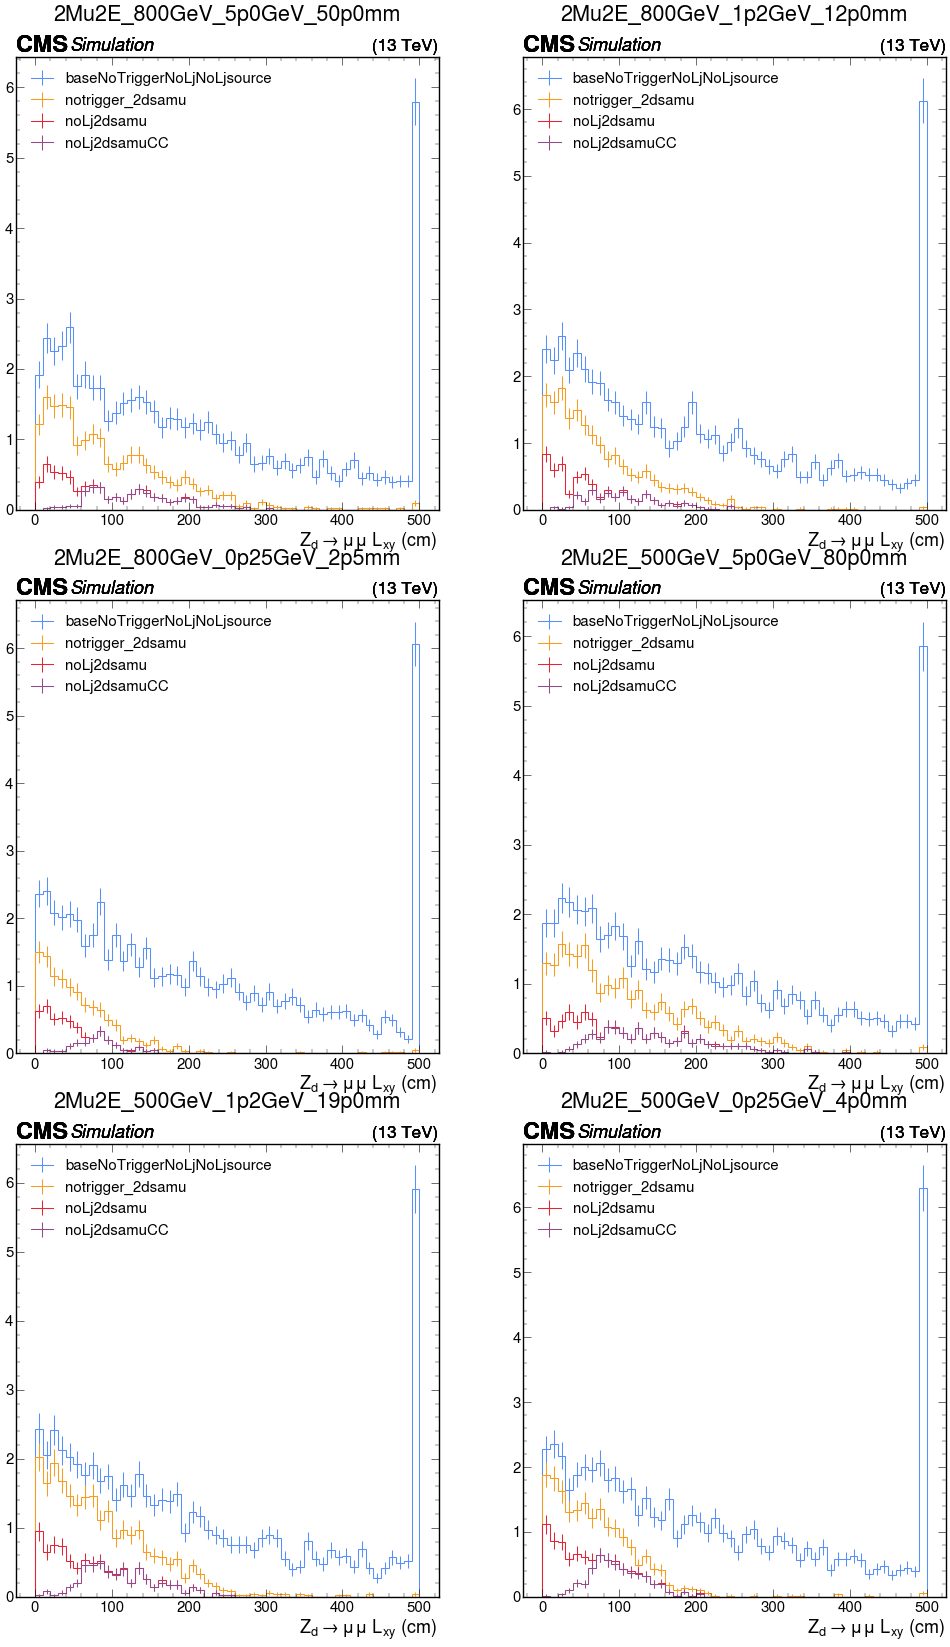

In [8]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 2
    channel3 = 4
    channel4 = 6
    channel5 = 8
    #channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
   #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

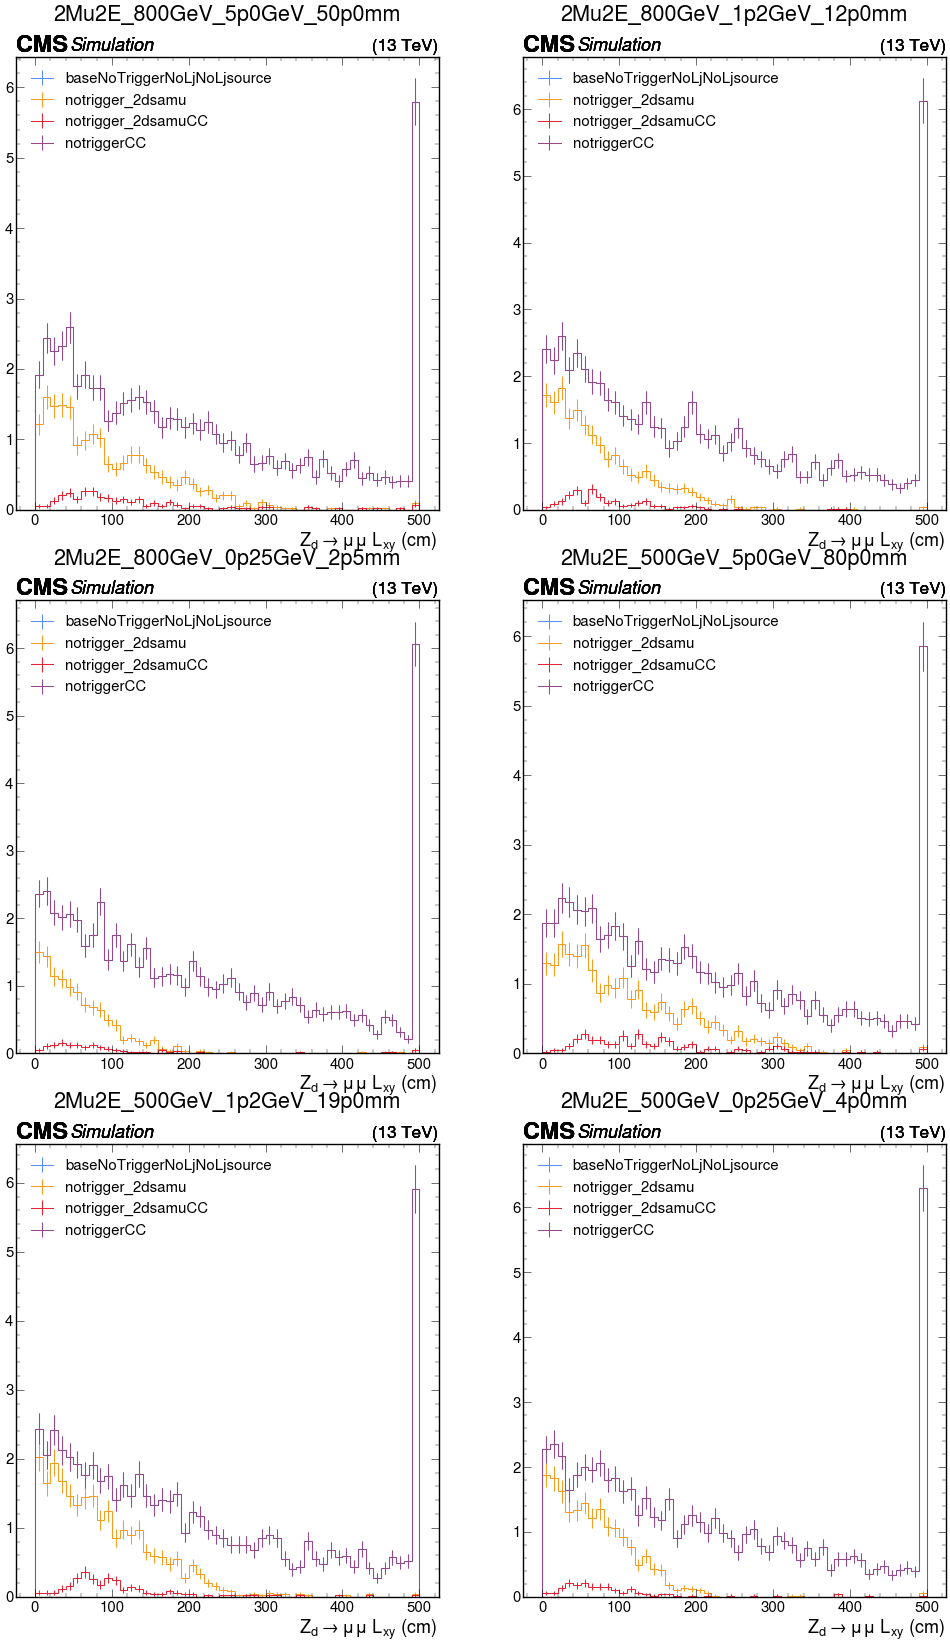

In [9]:
plt.subplots(3, 2, figsize=(24, 40))
for i in range(6):
    plt.subplot(3, 2, i+1)
    channel1 = 0
    channel2 = 2
    channel3 = 4
    channel4 = 6
    #channel5 = 11
    #channel6 = 5
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

/usr/local/lib/python3.12/site-packages/sidm/tools/utilities.py:159: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals


Text(0.5, 3.1, 'Muon Cuts')

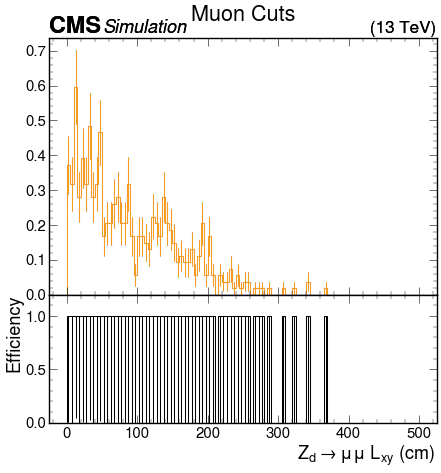

In [4]:
utilities.plot_ratio(out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[1], :],out[samples[0]]["hists"]["genAs_toMu_lxy"][channels[3], :])
plt.title("Muon Cuts",y=3.1)